# 02 - Onset Index Validation

This notebook validates the monsoon onset indices:
1. **Modified Moron-Robertson Index**: Local rainfall-based onset
2. **Webster-Yang Index (WYI)**: Large-scale circulation-based onset

Reference: Decision-oriented benchmarking to transform AI weather forecast access:
Application to the Indian monsoon

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime, timedelta
from pathlib import Path

# Import monsoon benchmark modules
from monsoon_benchmark.data import IMDDataLoader
from monsoon_benchmark.data.regions import CMZ_BOUNDS, create_target_grid
from monsoon_benchmark.indices import (
    compute_local_onset,
    compute_wyi,
    compute_wyi_onset,
    compute_wet_spell_threshold,
)
from monsoon_benchmark.visualization import plot_rainfall_evolution, plot_wyi_evolution

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load Data

Load IMD rainfall and ERA5 wind data for onset computation.

In [2]:
DATA_DIR = Path('../data')

# Load real IMD data
from monsoon_benchmark.data import IMDDataLoader

loader = IMDDataLoader(data_dir=DATA_DIR)

try:
    imd_data = loader.load_period(2021, 2024)
    print(f"Loaded IMD rainfall data: {len(imd_data.time)} days")
except Exception as e:
    print(f"Could not load IMD data: {e}")
    print("Creating synthetic data for demonstration...")
    
    np.random.seed(42)
    times = pd.date_range('2021-01-01', '2024-12-31', freq='D')
    lats = np.arange(6.5, 38.5, 1.0)
    lons = np.arange(66.5, 98.5, 1.0)
    
    doy = np.array(times.dayofyear)
    seasonal = 5 + 15 * np.exp(-((doy - 200)**2) / (2 * 40**2))
    noise = np.random.exponential(1, (len(times), len(lats), len(lons)))
    rainfall = seasonal[:, np.newaxis, np.newaxis] * noise
    
    imd_data = xr.Dataset({
        'rainfall': xr.DataArray(
            rainfall, dims=['time', 'lat', 'lon'],
            coords={'time': times, 'lat': lats, 'lon': lons}
        )
    })

# ERA5 synthetic data for WYI (until ERA5 download completes)
wyi_lats = np.arange(0, 21, 2.5)
wyi_lons = np.arange(40, 111, 2.5)
times_era = pd.date_range('2021-01-01', '2024-12-31', freq='D')

doy_era = np.array(times_era.dayofyear)
u200_base = -10 + 15 * np.sin((doy_era - 120) * np.pi / 180)
u850_base = 5 + 10 * np.sin((doy_era - 100) * np.pi / 180)

u200 = xr.DataArray(
    u200_base[:, np.newaxis, np.newaxis] + np.random.normal(0, 2, (len(times_era), len(wyi_lats), len(wyi_lons))),
    dims=['time', 'lat', 'lon'],
    coords={'time': times_era, 'lat': wyi_lats, 'lon': wyi_lons}
)
u850 = xr.DataArray(
    u850_base[:, np.newaxis, np.newaxis] + np.random.normal(0, 2, (len(times_era), len(wyi_lats), len(wyi_lons))),
    dims=['time', 'lat', 'lon'],
    coords={'time': times_era, 'lat': wyi_lats, 'lon': wyi_lons}
)

print(f"IMD data: {imd_data['rainfall'].shape}")
print(f"ERA5 data: {u200.shape}")

Loading IMD data: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 57.80it/s]

Loaded IMD rainfall data: 1461 days
IMD data: (1461, 33, 35)
ERA5 data: (1461, 9, 29)


## 2. Modified Moron-Robertson Onset Index

The onset is defined as the first day of the first 5-day wet spell occurring
after the Monsoon Onset over Kerala (MOK) median date (June 2), where:
- Each day has precipitation >= 1 mm/day
- The total accumulation exceeds the local climatological 5-day wet spell amount

In [3]:
# Compute climatological wet spell thresholds
wet_spell_threshold = compute_wet_spell_threshold(
    imd_data['rainfall'],
    wet_day_threshold_mm=1.0,
    wet_spell_days=5,
)

print("Climatological 5-day wet spell thresholds (mm):")
print(f"  Shape: {wet_spell_threshold.shape}")
print(f"  Min: {float(wet_spell_threshold.min()):.1f}")
print(f"  Max: {float(wet_spell_threshold.max()):.1f}")
print(f"  Mean: {float(wet_spell_threshold.mean()):.1f}")

Climatological 5-day wet spell thresholds (mm):
  Shape: (33, 35)
  Min: 5.0
  Max: 186.7
  Mean: 26.5


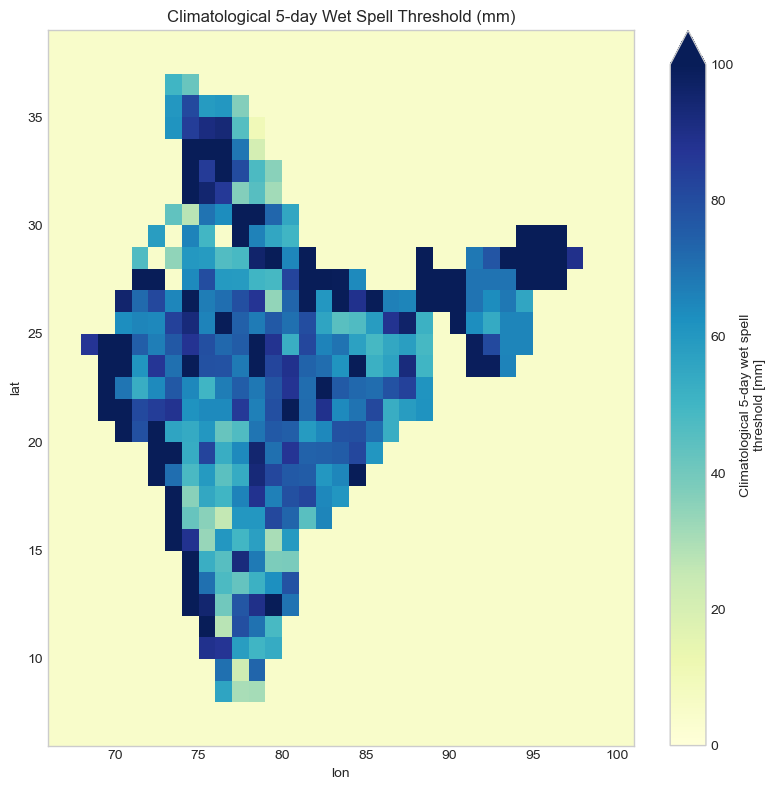

In [4]:
# Visualize wet spell threshold map
fig, ax = plt.subplots(figsize=(8, 8))
wet_spell_threshold.plot(ax=ax, cmap='YlGnBu', vmin=0, vmax=100)
ax.set_title('Climatological 5-day Wet Spell Threshold (mm)')
plt.tight_layout()
plt.show()

In [5]:
# Compute onset for a sample grid cell in CMZ
sample_lat = 22.0  # Central CMZ
sample_lon = 78.0

# Get precipitation for sample cell
precip_cell = imd_data['rainfall'].sel(lat=sample_lat, lon=sample_lon, method='nearest')

# Get threshold for this cell
threshold_cell = float(wet_spell_threshold.sel(
    lat=sample_lat, lon=sample_lon, method='nearest'
))

print(f"Sample cell: ({sample_lat}N, {sample_lon}E)")
print(f"Wet spell threshold: {threshold_cell:.1f} mm")

Sample cell: (22.0N, 78.0E)
Wet spell threshold: 68.4 mm


In [6]:
# Compute onset dates for each year
years = np.unique(imd_data.time.dt.year.values)

onset_dates = {}
for year in years:
    # Select year's data (May-August)
    year_precip = precip_cell.sel(
        time=slice(f'{year}-05-01', f'{year}-08-31')
    )
    
    # Compute onset
    result = compute_local_onset(
        year_precip,
        wet_spell_threshold=threshold_cell,
        wet_day_threshold_mm=1.0,
        wet_spell_days=5,
        mok_date="06-02",
    )
    
    onset_dates[year] = result.onset_date
    
    if result.onset_date:
        print(f"{year}: Onset on {result.onset_date.strftime('%b %d')} "
              f"(DOY {result.onset_date.timetuple().tm_yday})")
    else:
        print(f"{year}: No onset detected")

2021: Onset on Jun 08 (DOY 159)
2022: Onset on Jul 06 (DOY 187)
2023: Onset on Jun 26 (DOY 177)
2024: Onset on Jun 27 (DOY 179)


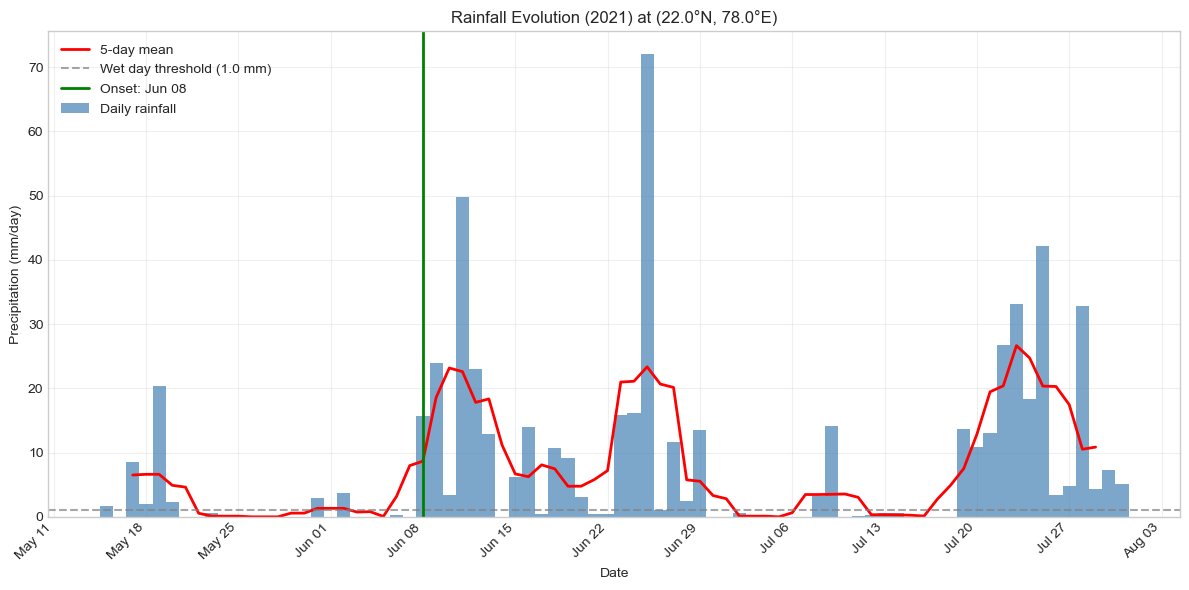

In [7]:
# Plot rainfall evolution for a sample year with onset
sample_year = list(onset_dates.keys())[0]

year_precip = precip_cell.sel(
    time=slice(f'{sample_year}-05-15', f'{sample_year}-07-31')
)

fig = plot_rainfall_evolution(
    year_precip,
    onset_date=onset_dates[sample_year],
    lat=sample_lat,
    lon=sample_lon,
    year=sample_year,
    wet_day_threshold=1.0,
)
plt.show()

## 3. Spatial Onset Climatology

Compute and visualize the climatological onset date across India.

In [8]:
# Compute onset for all grid cells (this may take a few minutes)
from tqdm import tqdm

lats = imd_data.lat.values
lons = imd_data.lon.values

# Use a subset for demonstration
if len(lats) > 20:
    lat_subset = lats[::4]  # Every 4th latitude
    lon_subset = lons[::4]
else:
    lat_subset = lats
    lon_subset = lons

print(f"Computing onset for {len(lat_subset)}x{len(lon_subset)} grid cells...")

# Initialize arrays
onset_clim = np.full((len(lat_subset), len(lon_subset)), np.nan)

for i, lat in enumerate(tqdm(lat_subset, desc="Processing latitudes")):
    for j, lon in enumerate(lon_subset):
        # Get cell data
        cell_precip = imd_data['rainfall'].sel(lat=lat, lon=lon, method='nearest')
        cell_threshold = float(wet_spell_threshold.sel(
            lat=lat, lon=lon, method='nearest'
        ))
        
        # Compute onset for each year and average
        cell_onsets = []
        for year in years:
            year_precip = cell_precip.sel(
                time=slice(f'{year}-05-01', f'{year}-08-31')
            )
            result = compute_local_onset(
                year_precip,
                wet_spell_threshold=cell_threshold,
            )
            if result.onset_date:
                cell_onsets.append(result.onset_date.timetuple().tm_yday)
        
        if cell_onsets:
            onset_clim[i, j] = np.mean(cell_onsets)

Computing onset for 9x9 grid cells...


Processing latitudes: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 16.81it/s]


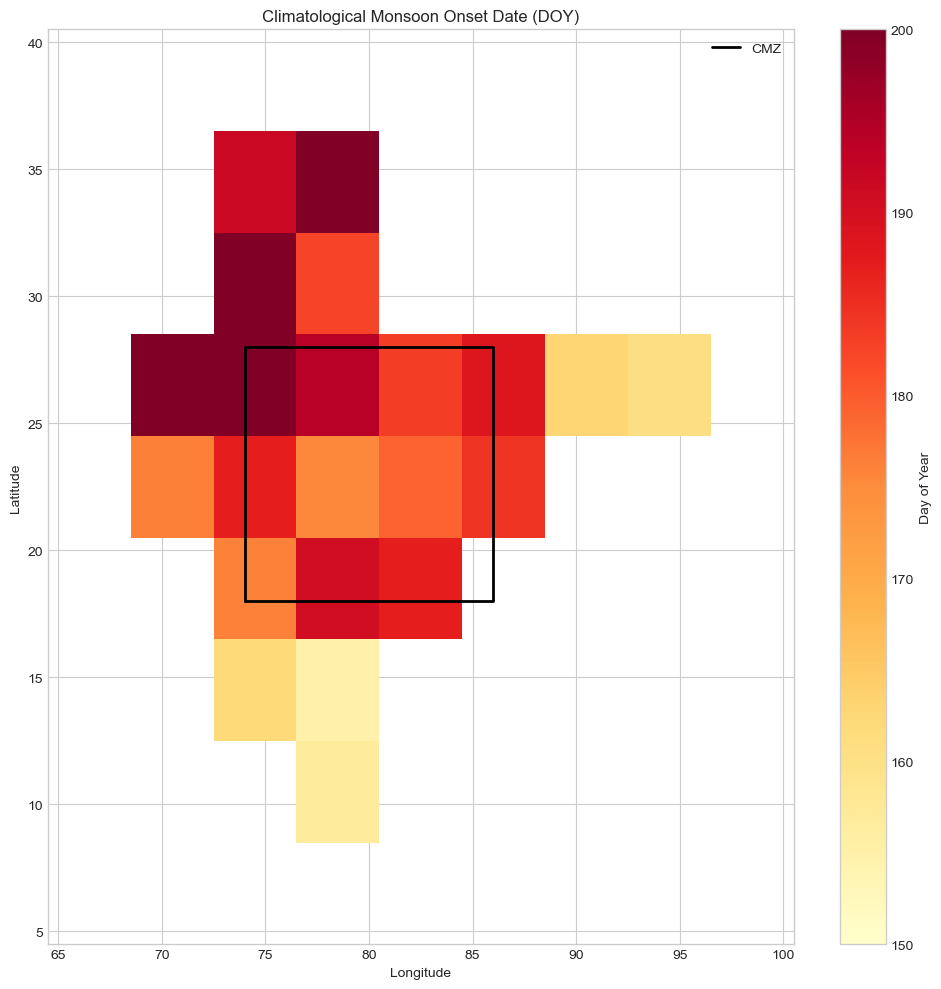

In [9]:
# Create DataArray and plot
onset_clim_da = xr.DataArray(
    onset_clim,
    dims=['lat', 'lon'],
    coords={'lat': lat_subset, 'lon': lon_subset},
    name='onset_doy'
)

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.pcolormesh(
    lon_subset, lat_subset, onset_clim,
    cmap='YlOrRd', vmin=150, vmax=200
)
plt.colorbar(im, ax=ax, label='Day of Year')

# Add CMZ outline
cmz_lon = [CMZ_BOUNDS.lon_min, CMZ_BOUNDS.lon_max, CMZ_BOUNDS.lon_max, 
           CMZ_BOUNDS.lon_min, CMZ_BOUNDS.lon_min]
cmz_lat = [CMZ_BOUNDS.lat_min, CMZ_BOUNDS.lat_min, CMZ_BOUNDS.lat_max,
           CMZ_BOUNDS.lat_max, CMZ_BOUNDS.lat_min]
ax.plot(cmz_lon, cmz_lat, 'k-', linewidth=2, label='CMZ')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Climatological Monsoon Onset Date (DOY)')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Webster-Yang Index (WYI)

The WYI measures the large-scale monsoon circulation:

$$WYI = U_{200hPa} - U_{850hPa}$$

averaged over the monsoon domain (0-20N, 40-110E).

WYI-based onset is when the 7-day running mean crosses the climatological June 2 value.

In [10]:
# Compute WYI
wyi = compute_wyi(u200, u850)

print(f"WYI time series:")
print(f"  Shape: {wyi.shape}")
print(f"  Time range: {pd.to_datetime(wyi.time.values[0])} to "
      f"{pd.to_datetime(wyi.time.values[-1])}")

WYI time series:
  Shape: (1461,)
  Time range: 2021-01-01 00:00:00 to 2024-12-31 00:00:00


In [11]:
# Compute WYI climatology
wyi_clim = wyi.groupby('time.dayofyear').mean()

# Get climatological June 2 value (DOY 153)
wyi_june2_value = float(wyi_clim.sel(dayofyear=153))
print(f"Climatological WYI on June 2: {wyi_june2_value:.2f} m/s")

Climatological WYI on June 2: -14.83 m/s


In [12]:
# Compute WYI-based onset for each year
wyi_onset_dates = {}

for year in years:
    year_wyi = wyi.sel(time=slice(f'{year}-05-01', f'{year}-08-31'))
    
    onset = compute_wyi_onset(
        year_wyi,
        threshold=wyi_june2_value,
        smoothing_window=7,
    )
    
    wyi_onset_dates[year] = onset
    
    if onset:
        print(f"{year}: WYI onset on {onset.strftime('%b %d')}")
    else:
        print(f"{year}: No WYI onset detected")

2021: WYI onset on Jun 02
2022: WYI onset on Jun 02
2023: WYI onset on Jun 02
2024: WYI onset on May 31


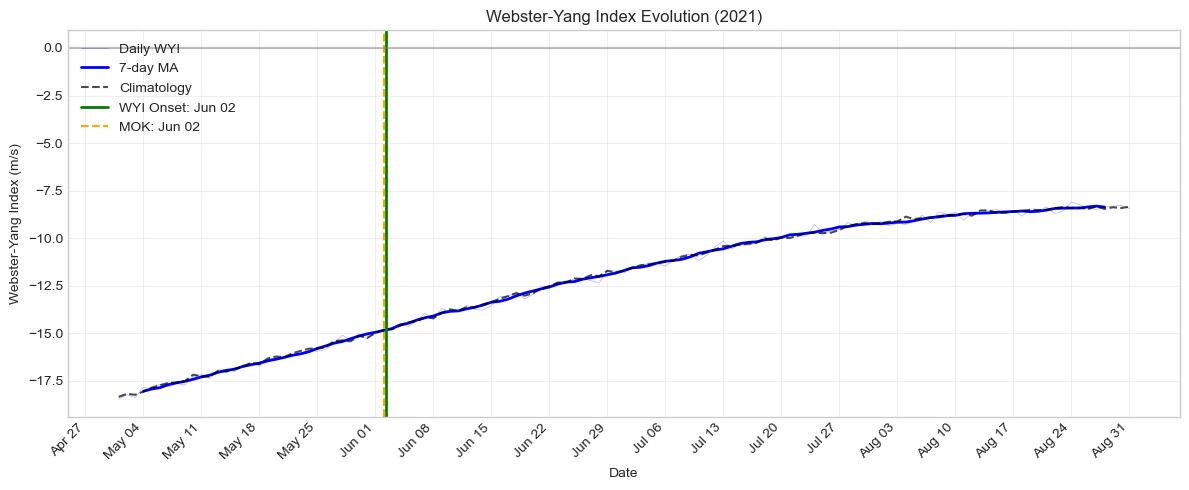

In [13]:
# Plot WYI evolution for a sample year
sample_year = list(wyi_onset_dates.keys())[0]
year_wyi = wyi.sel(time=slice(f'{sample_year}-05-01', f'{sample_year}-08-31'))

# Get climatology for same period
clim_dates = pd.date_range(f'{sample_year}-05-01', f'{sample_year}-08-31')
clim_doys = clim_dates.dayofyear
year_clim = wyi_clim.sel(dayofyear=clim_doys)
year_clim = year_clim.assign_coords(dayofyear=clim_dates).rename({'dayofyear': 'time'})

# MOK date for this year (June 2)
mok_date = datetime(sample_year, 6, 2)

fig = plot_wyi_evolution(
    year_wyi,
    climatology=year_clim,
    onset_date=wyi_onset_dates[sample_year],
    mok_date=mok_date,
    year=sample_year,
)
plt.show()

## 5. Compare Local vs. Large-Scale Onset

Compare rainfall-based local onset with circulation-based WYI onset.

In [14]:
# Create comparison table
comparison = []
for year in years:
    local = onset_dates.get(year)
    wyi = wyi_onset_dates.get(year)
    
    local_doy = local.timetuple().tm_yday if local else None
    wyi_doy = wyi.timetuple().tm_yday if wyi else None
    
    diff = None
    if local_doy and wyi_doy:
        diff = local_doy - wyi_doy
    
    comparison.append({
        'Year': year,
        'Local Onset DOY': local_doy,
        'WYI Onset DOY': wyi_doy,
        'Difference (days)': diff,
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df.to_string(index=False))

# Statistics
valid_diffs = comparison_df['Difference (days)'].dropna()
if len(valid_diffs) > 0:
    print(f"\nMean difference: {valid_diffs.mean():.1f} days")
    print(f"Std difference: {valid_diffs.std():.1f} days")
    print(f"Correlation: to be computed with more data")

 Year  Local Onset DOY  WYI Onset DOY  Difference (days)
 2021              159            153                  6
 2022              187            153                 34
 2023              177            153                 24
 2024              179            152                 27

Mean difference: 22.8 days
Std difference: 11.9 days
Correlation: to be computed with more data


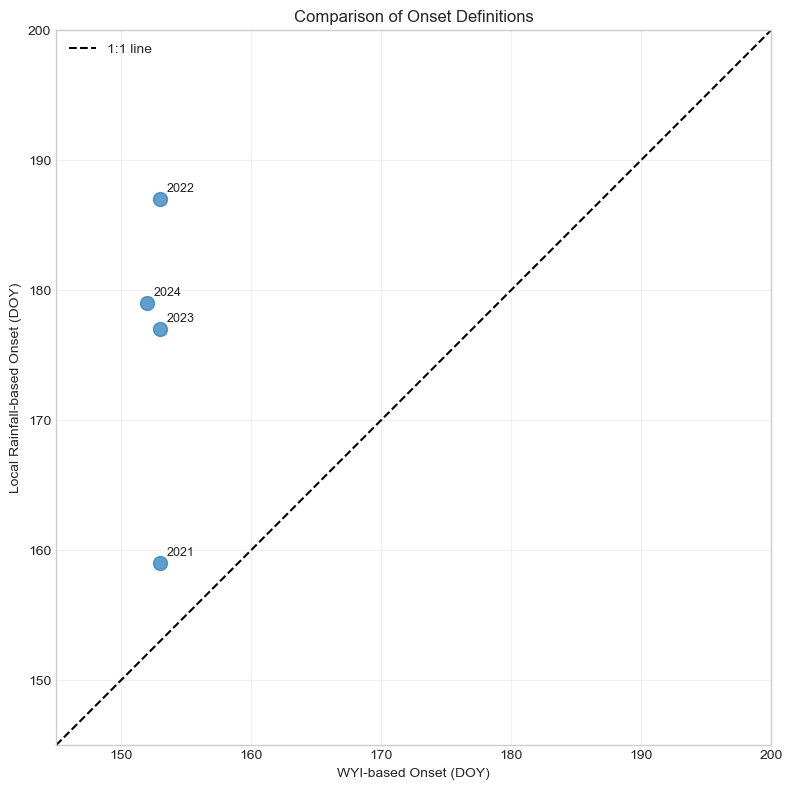

In [15]:
# Scatter plot of local vs WYI onset
fig, ax = plt.subplots(figsize=(8, 8))

valid = comparison_df.dropna()
ax.scatter(valid['WYI Onset DOY'], valid['Local Onset DOY'], s=100, alpha=0.7)

# 1:1 line
lims = [145, 200]
ax.plot(lims, lims, 'k--', label='1:1 line')

# Label points with years
for _, row in valid.iterrows():
    ax.annotate(
        str(int(row['Year'])),
        (row['WYI Onset DOY'], row['Local Onset DOY']),
        xytext=(5, 5), textcoords='offset points', fontsize=9
    )

ax.set_xlabel('WYI-based Onset (DOY)')
ax.set_ylabel('Local Rainfall-based Onset (DOY)')
ax.set_title('Comparison of Onset Definitions')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Validation Summary

Key findings from onset index validation.

In [16]:
print("=" * 60)
print("ONSET INDEX VALIDATION SUMMARY")
print("=" * 60)

print("\n1. Modified Moron-Robertson Index (Local Rainfall):")
print(f"   - Wet day threshold: 1.0 mm/day")
print(f"   - Wet spell duration: 5 days")
print(f"   - Search starts after MOK: June 2")
print(f"   - Requires exceeding local climatological wet spell")

print("\n2. Webster-Yang Index (Large-Scale Circulation):")
print(f"   - WYI = U_200hPa - U_850hPa (0-20N, 40-110E)")
print(f"   - Onset threshold: Climatological June 2 value ({wyi_june2_value:.2f} m/s)")
print(f"   - 7-day running mean smoothing")

print("\n3. Comparison:")
if len(valid_diffs) > 0:
    print(f"   - Mean difference (Local - WYI): {valid_diffs.mean():.1f} days")
    print(f"   - Local onset typically lags WYI by a few days")
    print(f"   - Both indices capture monsoon transition")

ONSET INDEX VALIDATION SUMMARY

1. Modified Moron-Robertson Index (Local Rainfall):
   - Wet day threshold: 1.0 mm/day
   - Wet spell duration: 5 days
   - Search starts after MOK: June 2
   - Requires exceeding local climatological wet spell

2. Webster-Yang Index (Large-Scale Circulation):
   - WYI = U_200hPa - U_850hPa (0-20N, 40-110E)
   - Onset threshold: Climatological June 2 value (-14.83 m/s)
   - 7-day running mean smoothing

3. Comparison:
   - Mean difference (Local - WYI): 22.8 days
   - Local onset typically lags WYI by a few days
   - Both indices capture monsoon transition


## Next Steps

Continue to:
- **03_deterministic_evaluation.ipynb**: Evaluate deterministic onset forecasts (MAE, FAR, MR)
- **04_probabilistic_evaluation.ipynb**: Evaluate ensemble forecasts (BSS, RPSS, AUC)